# Tilt along and perpendicular to the environmental PV gradient
Do AEs and CEs displace preferentially **with or against** the environmental PV gradient as depth increases?

Use **`PV_grad_mag` and `PV_grad_theta`**, the combined planetary + topographic gradient, with one surface reference per eddy-day. Positive along is toward increasing PV; positive perpendicular is 90° anticlockwise from that direction. Magnitude validates the reference; it does **not** weight the averages. No polarity-dependent flips.

We project each valid fitted centre's displacement from its own surface centre **before averaging**. This is a constituent-centre analysis; it needs no new velocity reconstruction or ESP fit. It measures surface-to-depth displacement, not the local derivative of the centreline.

Comparisons stay separate: overall AE/CE; S/U/D with low/high Rossby; planetary/mixed/topographic; low/high centre spread. Every comparison has shallow/deep rows, but we do not cross all categories. Physical and surface-`Rc` normalised displacements are both shown.

Mean estimates give equal weight to each available eddy-day. Pointwise 95% confidence intervals resample whole eddy tracks, retaining their available days and depths. They condition on the observed group classifications and median thresholds; they do not include ESP fit uncertainty or simultaneous confidence across depths. Days in a track can change categories; counts across groups must not be summed as distinct eddies.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
HERE = Path.cwd().resolve()
ANALYSIS = next((p for p in (HERE, *HERE.parents) if (p/'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS is None:
    candidate = HERE/'seacofs_eddy_tilt_analysis'
    ANALYSIS = candidate if (candidate/'seacofs_tilt_tools.py').exists() else None
if ANALYSIS is None: raise FileNotFoundError('Run from UNSW-PhD or seacofs_eddy_tilt_analysis or a subfolder')
WORK = ANALYSIS/'esp_population_composites'
for p in (ANALYSIS, WORK):
    if str(p) not in sys.path: sys.path.insert(0, str(p))
import seacofs_tilt_tools as tilt
import pv_relative_tilt_tools as pvt
pd.set_option('display.max_columns', 60)

In [2]:
# Cache False computes and overwrites the ONE existing surface PV cache;
# True reuses it, checking that these calculation settings match.
USE_PV_CACHE = True
USE_MAX_ABS_W = True
W_MAX_DEPTH_M = 1000.
ELLIPSE_FRAC = 1.
SPLIT_DEPTH_M = 1000.       # shallow <= 1000; deep > 1000, deepest valid fit
SPREAD_MAX_DEPTH_M = 1000. # largest pairwise centre distance in this window
ROSSBY_SPLIT = .5          # low |Ro| < .5; high >= .5
DOMINANCE_FACTOR = 2.      # plan >= 2*topo; topo >= 2*plan; otherwise mixed
CANCELLATION_MIN = .1      # sensitivity only; baseline retains every valid direction
BOOTSTRAPS = 500
SEED = 731
MIN_PLOT_EDDIES = 2
SPARSE_EDDIES = 20
DIRECTION_DEPTHS_M = [200., 500., 1000., 1500.]
DEPTH_TOLERANCE_M = 100.
MATCH_TARGETS_M = {'shallow': [200.,500.], 'deep': [200.,500.,1000.,1500.]}
RUN_MATCHED_SENSITIVITY = True
SAVE_RESULTS = False
OUTPUT = WORK/'pv_relative_tilt_results'
# These summaries use all exact valid fitted depths, including those below 1000 m.

## Load and audit the population
Existing fit validity is reused: finite fitted parameters, positive Rc, positive-definite ellipse, nonnegative depth, and a valid surface fit. Invalid/nonpositive PV magnitudes and invalid bearings cannot define a frame and are excluded with an explicit reason. Unknown regions/Rossby/dominance remain in the overall population, but not in their corresponding subgroup plots.

The PV function uses the signed largest-|w| sample in the upper 1000 m for Ro and w-dependent PV terms. It retains surface ellipse geometry. Refresh the single cache with `USE_PV_CACHE=False` if its settings or source data have changed.

In [3]:
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
surface, _ = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)
vertical = tilt.load_vert(paths)
surface = tilt.add_pv_gradient_terms(
    surface, grid, core_mean=True, frac=ELLIPSE_FRAC,
    surface_method='esp_gaussian', averaging='nonlinear',
    use_max_abs_w=USE_MAX_ABS_W, max_depth_m=W_MAX_DEPTH_M,
    vertical=vertical, use_cache=USE_PV_CACHE,
)
surface = tilt.add_region_labels(surface, grid)
day_audit, members, spread_thresholds = pvt.prepare_members(
    surface, vertical, grid.angle, split_depth=SPLIT_DEPTH_M,
    spread_depth=SPREAD_MAX_DEPTH_M, ro_split=ROSSBY_SPLIT,
    dominance_factor=DOMINANCE_FACTOR, cancellation_min=CANCELLATION_MIN,
)
if members.empty: raise ValueError('No eligible PV-relative profiles; inspect day_audit')
display(day_audit.groupby('analysis_status', dropna=False).agg(eddy_days=('Day','size'), eddies=('Eddy','nunique')))
print('Eligible eddy-days:', len(members[['Eddy','Day']].drop_duplicates()), '| tracks:', members.Eddy.nunique())
print('Centres only: exact valid fitted levels, no reconstruction or interpolation.')

,eddy_days,eddies
analysis_status,,
included,120543,2982
no valid surface fit,6883,2068


Eligible eddy-days: 120543 | tracks: 2982
Centres only: exact valid fitted levels, no reconstruction or interpolation.


## Centre spread and coverage
**Centre spread** is the largest pairwise horizontal distance between any two valid centres at 0–1000 m for that eddy-day. At least two fitted levels are required; missing values stay unclassified. This can exceed maximum displacement from the surface when the centreline curves.

Within each shallow/deep cohort, take the median kilometre spread across eligible eddy-days **pooling AE/CE, all regions, Rossby classes and PV regimes**. Low is below that median; high is at or above it. Ties need not produce equally sized groups. These thresholds stay fixed for all sensitivity checks.

The common 1000 m upper bound does not guarantee equal sampled depth ranges: shallow profiles may end earlier. The table below reports coverage by spread class. High/low spread is a descriptive, outcome-based comparison, not independent evidence for a tilt mechanism.

In [4]:
display(spread_thresholds)
eligible = day_audit.loc[day_audit.analysis_status.eq('included')]
spread_coverage = eligible.groupby(['extent_group','spread_class','Cyc'], dropna=False).agg(
    eddy_days=('Day','size'), eddies=('Eddy','nunique'),
    median_spread_km=('centre_spread_km','median'),
    median_sampled_depth_m=('spread_max_depth_m','median'),
    p10_sampled_depth_m=('spread_max_depth_m',lambda x:x.quantile(.1)),
    median_levels=('spread_levels','median'),
)
display(spread_coverage)
print('Unknown categories retained in overall analysis:')
for column in ['Region_group','Ro_class','PV_regime','spread_class']:
    display(eligible[column].value_counts(dropna=False).rename(column))

,extent_group,spread_threshold_km,classified_days
0,shallow,30.326514,39797
1,deep,23.237770,80746


eddy_days  eddies  median_spread_km  \
extent_group spread_class Cyc                                        
deep         high         AE       21221    1253         37.225066   
                          CE       19152    1414         35.263433   
             low          AE       17918     896         15.079489   
                          CE       22455    1225         14.192975   
shallow      high         AE       11381    1304         49.124144   
                          CE        8518    1252         46.748605   
             low          AE       11033    1304         19.302307   
                          CE        8865    1254         19.831993   

                               median_sampled_depth_m  p10_sampled_depth_m  \
extent_group spread_class Cyc                                                
deep         high         AE               858.918478           858.918478   
                          CE               858.918478           858.918478   
             low          AE               858.918478           858.918478   
                          CE               858.918478           858.918478   
shallow      high         AE               515.416489            88.116838   
                          CE               515.416489            60.170639   
             low          AE               266.206398            73.127842   
                          CE               407.922192            60.170639   

                               median_levels  
extent_group spread_class Cyc                 
deep         high         AE            22.0  
                          CE            22.0  
             low          AE            22.0  
                          CE            22.0  
shallow      high         AE            20.0  
                          CE            20.0  
             low          AE            17.0  
                          CE            19.0

Unknown categories retained in overall analysis:


Region_group
D    58864
U    39977
S    21702
Name: Region_group, dtype: int64

Ro_class
low     103434
high     17109
Name: Ro_class, dtype: int64

PV_regime
topographic    80873
mixed          31269
planetary       8401
Name: PV_regime, dtype: int64

spread_class
high    60272
low     60271
Name: spread_class, dtype: int64

## Estimate profiles and uncertainty
Normalise each constituent displacement by **its own surface Rc before averaging**. `profile_stats` contains signed means, variances, pointwise confidence limits, and distinct eddy/day counts at every exact fitted depth. `members` is the underlying projected-centre dataframe; `day_audit` holds the classification and exclusion record.

The with/against fraction uses days with a nonzero parallel component. Exactly perpendicular or zero vectors are neutral and counted separately. No distance weighting is applied. Fewer than two independent tracks gives no confidence interval; open circles flag fewer than 20 tracks in the profile figures.

In [5]:
profile_stats, group_inventory = pvt.analyse(members, n_boot=BOOTSTRAPS, seed=SEED)
with pd.option_context('display.max_rows', None): display(group_inventory)
support = profile_stats[pvt.GROUPS+['Depth','n_eddy_days','n_eddies','directional_days','neutral_days']].copy()
display(support)
# Example access: profile_stats.query("family == 'regional' and panel == 'S' and split == 'high'")

,family,panel,extent_group,split,Cyc,n_eddy_days,n_eddies
0,overall,All,shallow,all,AE,22414,1383
1,overall,All,shallow,all,CE,17383,1398
2,overall,All,deep,all,AE,39139,1269
3,overall,All,deep,all,CE,41607,1447
4,regional,S,shallow,low,AE,2869,290
5,regional,S,shallow,low,CE,2011,345
6,regional,S,shallow,high,AE,1103,140
7,regional,S,shallow,high,CE,1480,263
8,regional,S,deep,low,AE,2661,270
9,regional,S,deep,low,CE,5801,434


,family,panel,extent_group,split,Cyc,Depth,n_eddy_days,n_eddies,directional_days,neutral_days
0,overall,All,shallow,all,AE,0.000000,22414,1383,0,22414
1,overall,All,shallow,all,AE,5.879627,22414,1383,22414,0
2,overall,All,shallow,all,AE,10.725783,22414,1383,22414,0
3,overall,All,shallow,all,AE,16.383097,21914,1368,21914,0
4,overall,All,shallow,all,AE,22.925581,21623,1362,21623,0
...,...,...,...,...,...,...,...,...,...,...
1451,cancellation,All,deep,retained,CE,2568.677466,23409,1261,23409,0
1452,cancellation,All,deep,retained,CE,3252.716389,19781,1167,19781,0
1453,cancellation,All,deep,retained,CE,3930.053268,17441,1059,17441,0
1454,cancellation,All,deep,retained,CE,4460.447022,16339,994,16339,0


## Overall: AE versus CE
Rows are shallow/deep; columns are parallel/perpendicular. Positive along displacement indicates a mean centre shifted toward increasing environmental PV. Perpendicular sign records handedness, rather than with/against preference. Zero-centred axes make direction visible.

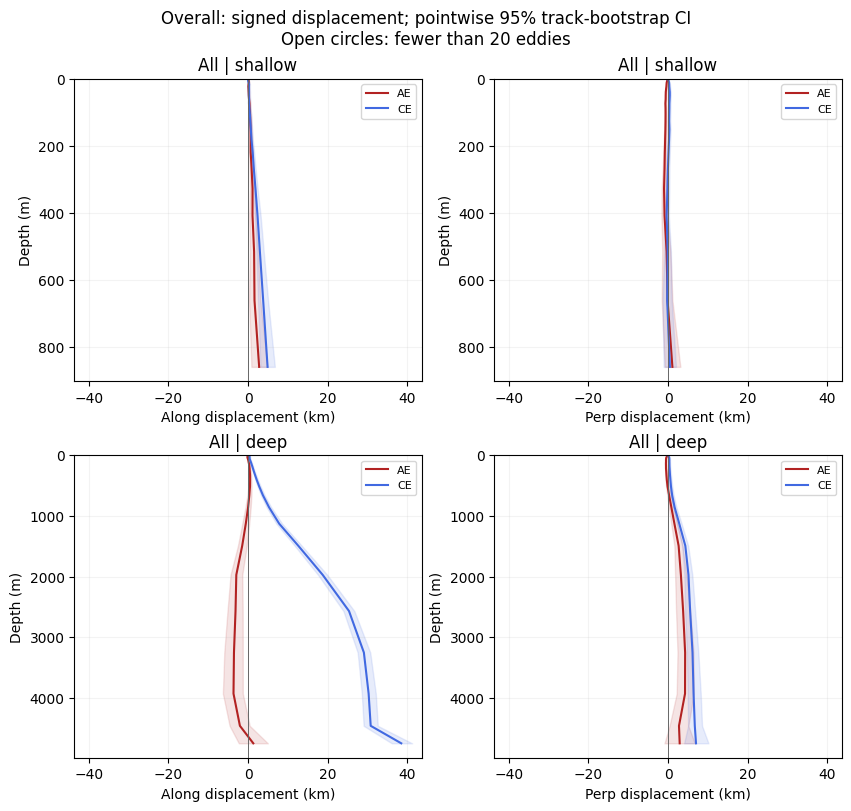

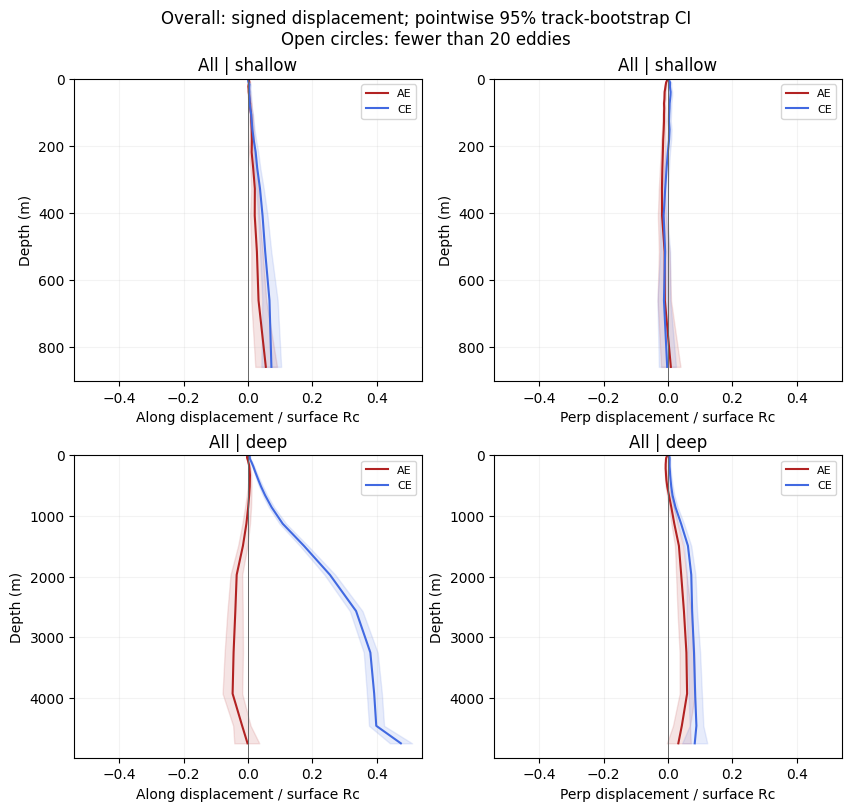

In [6]:
for unit in ['km','Rc']:
    pvt.plot_profiles(profile_stats, family='overall', unit=unit,
                      min_eddies=MIN_PLOT_EDDIES, sparse_eddies=SPARSE_EDDIES)
    plt.show()

## Regions S/U/D, with low/high Rossby
Pool raw S1+S2, U1+U2 and D1+D2 days before calculating statistics. Each figure is 2×3: shallow above deep, S/U/D across columns. Low Rossby is solid, high dashed; AE red, CE blue. This is the only comparison that crosses region with Rossby. Parallel and perpendicular components are shown separately, in km and /Rc.

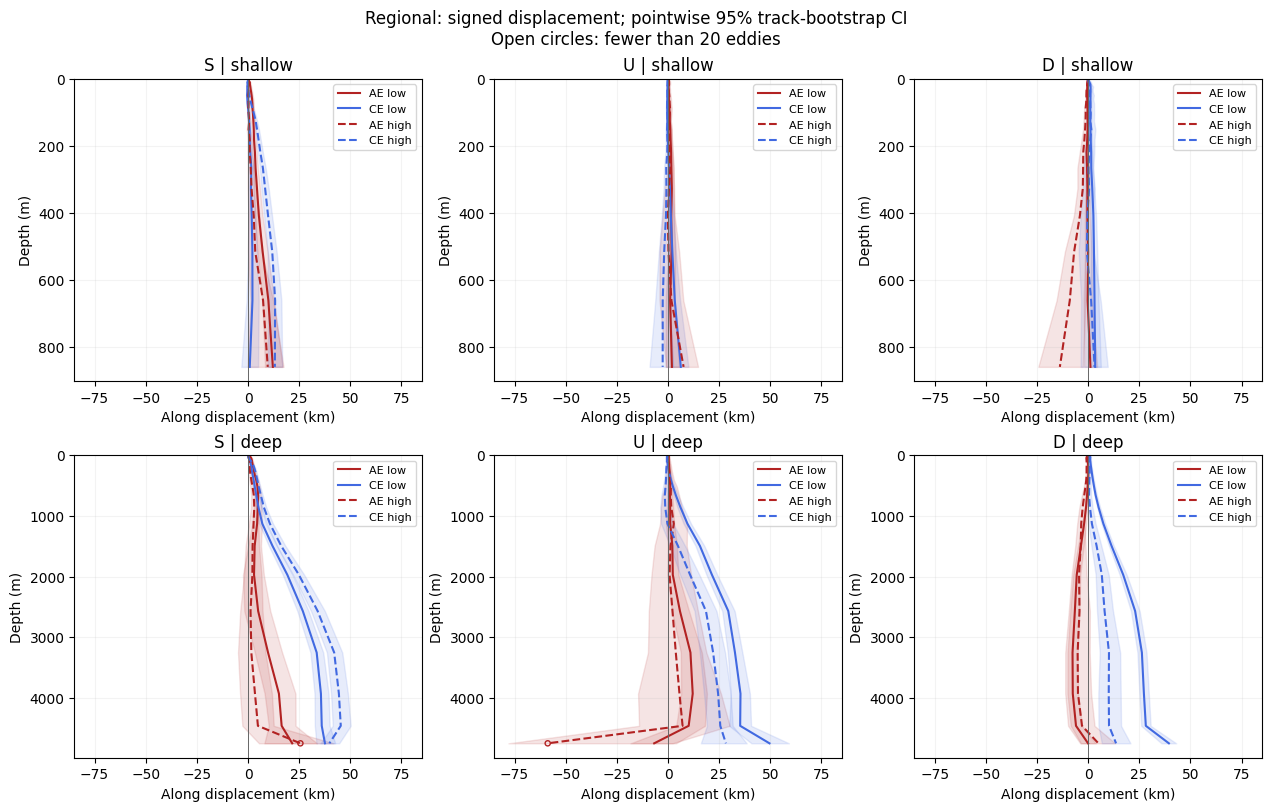

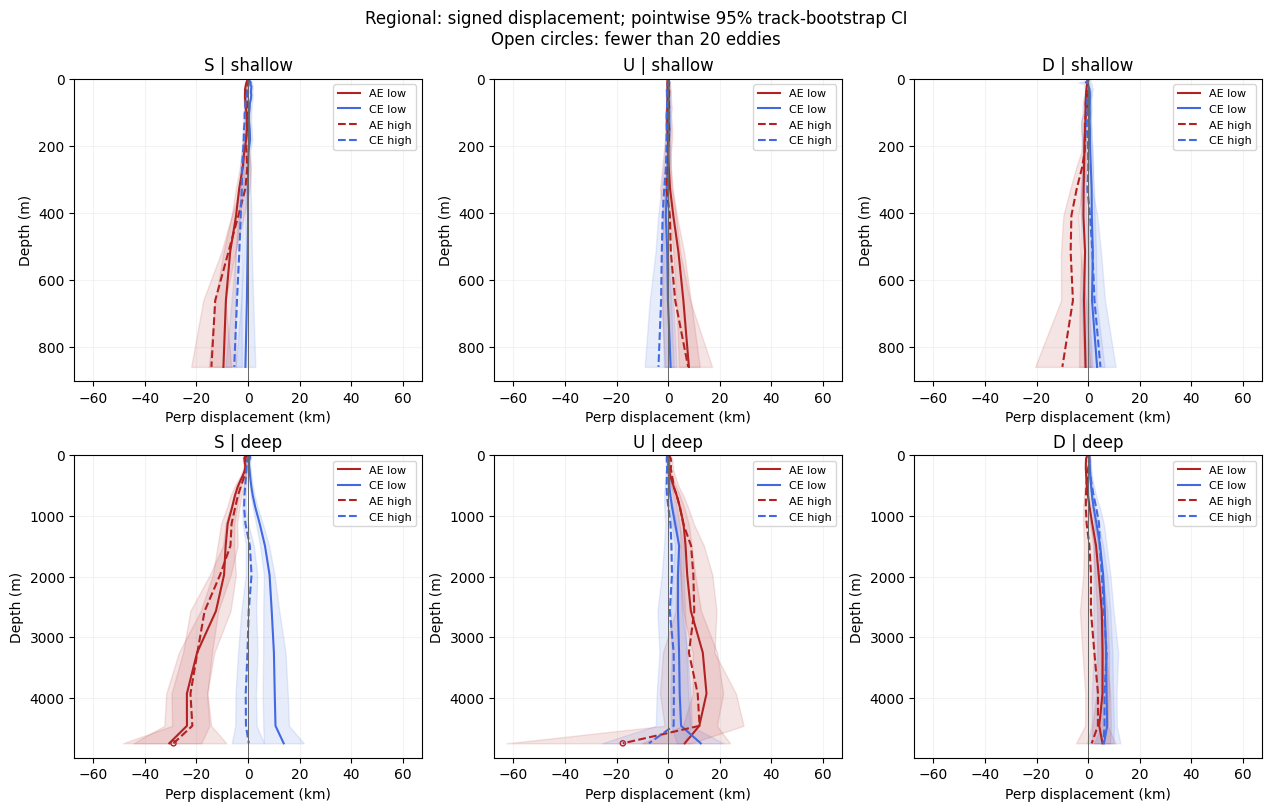

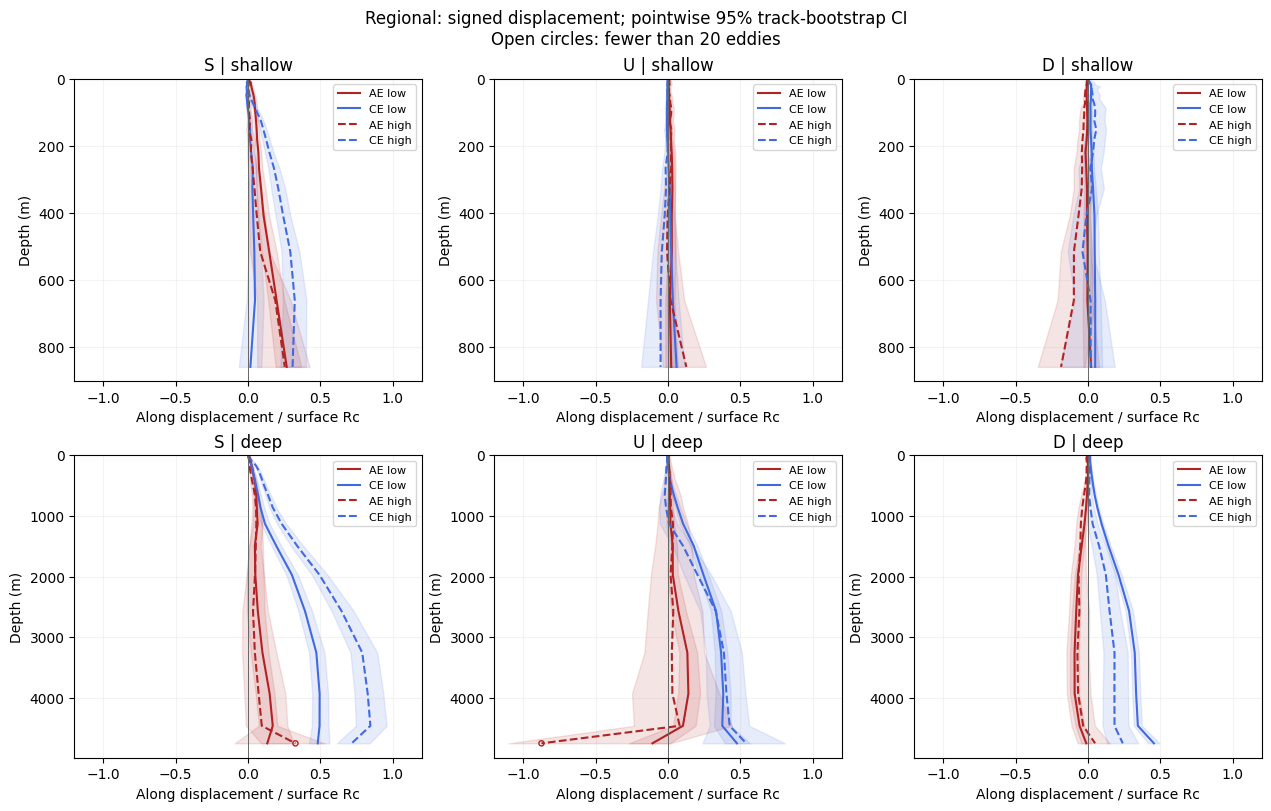

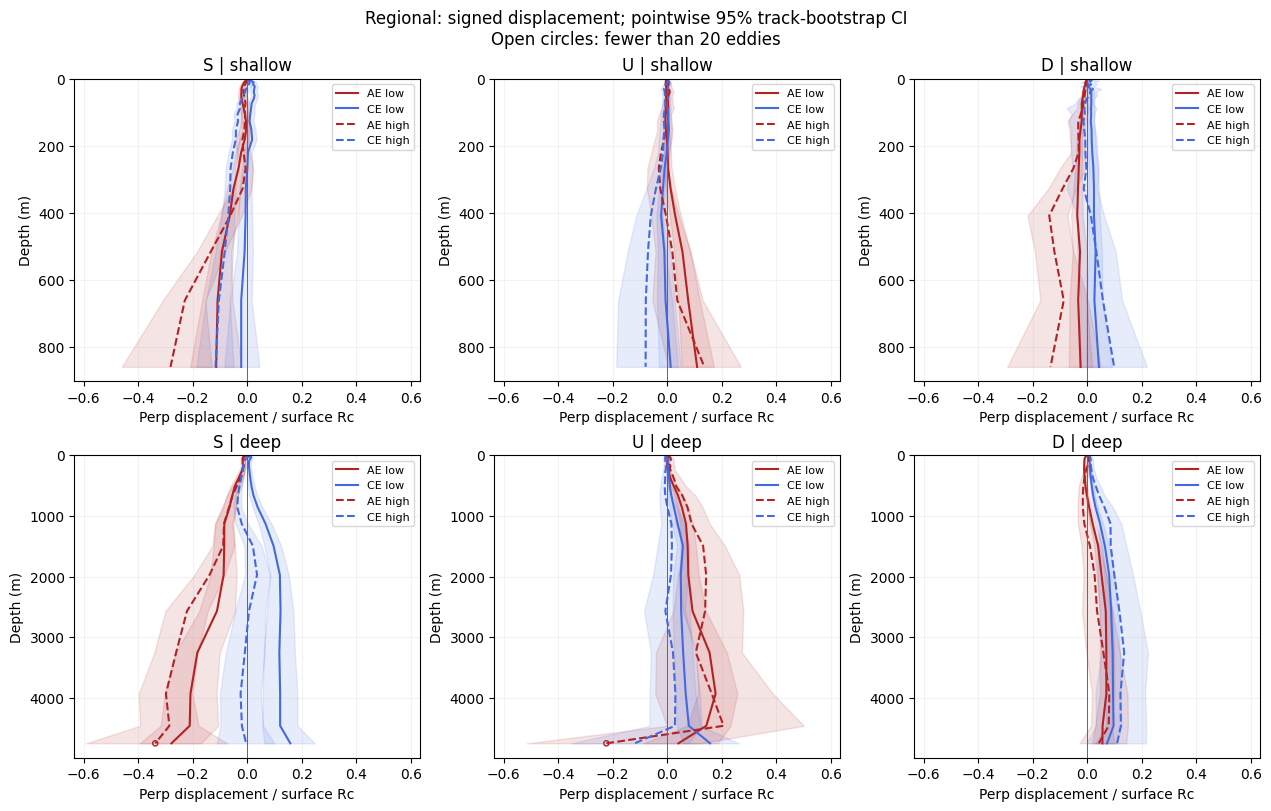

In [7]:
for unit in ['km','Rc']:
    for component in ['along','perp']:
        pvt.plot_profiles(profile_stats, family='regional', unit=unit, component=component,
                          min_eddies=MIN_PLOT_EDDIES, sparse_eddies=SPARSE_EDDIES)
        plt.show()

## Planetary, mixed and topographic populations
Dominance uses the component magnitudes: planetary ≥2×topographic, topographic ≥2×planetary, otherwise mixed (factor configurable above). Both zero or invalid components give unknown dominance. Every panel **still uses the combined `PV_grad_theta` direction**; the reference does not switch with the category. Regions and Rossby are pooled here.

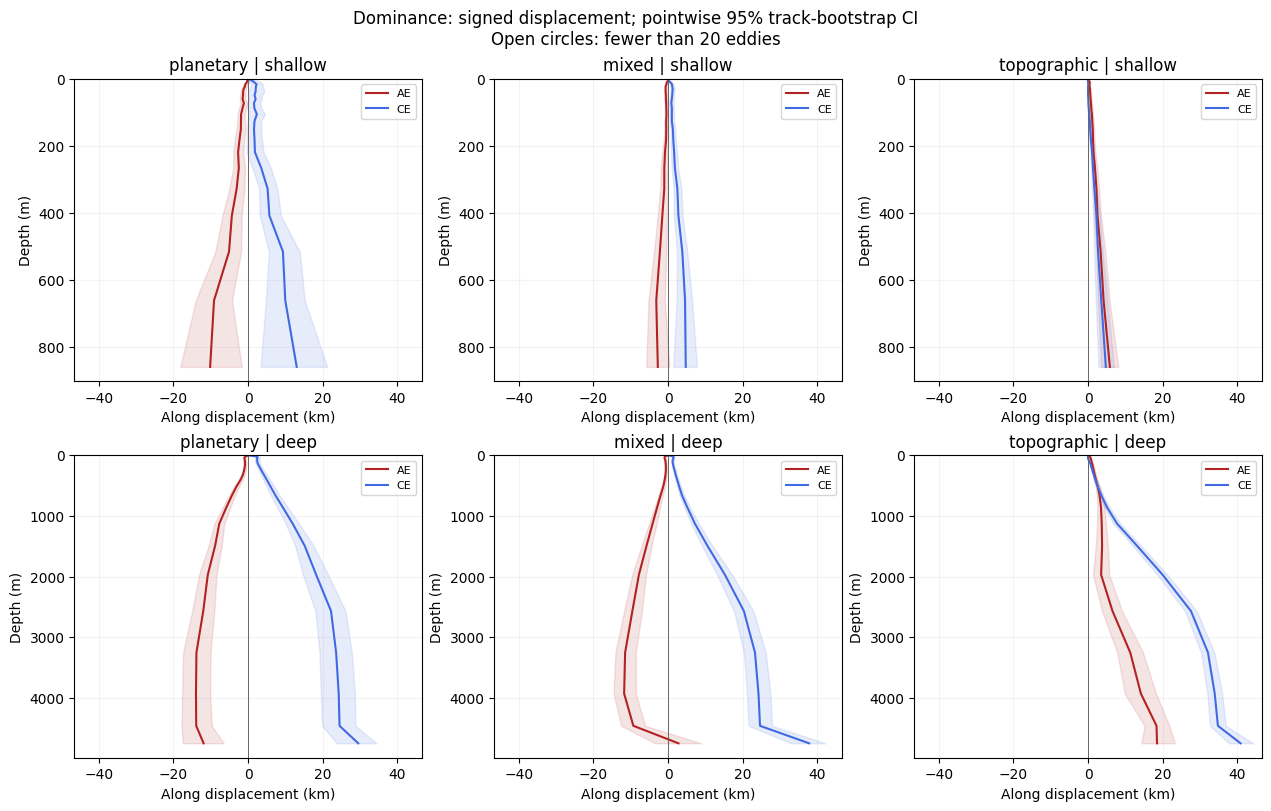

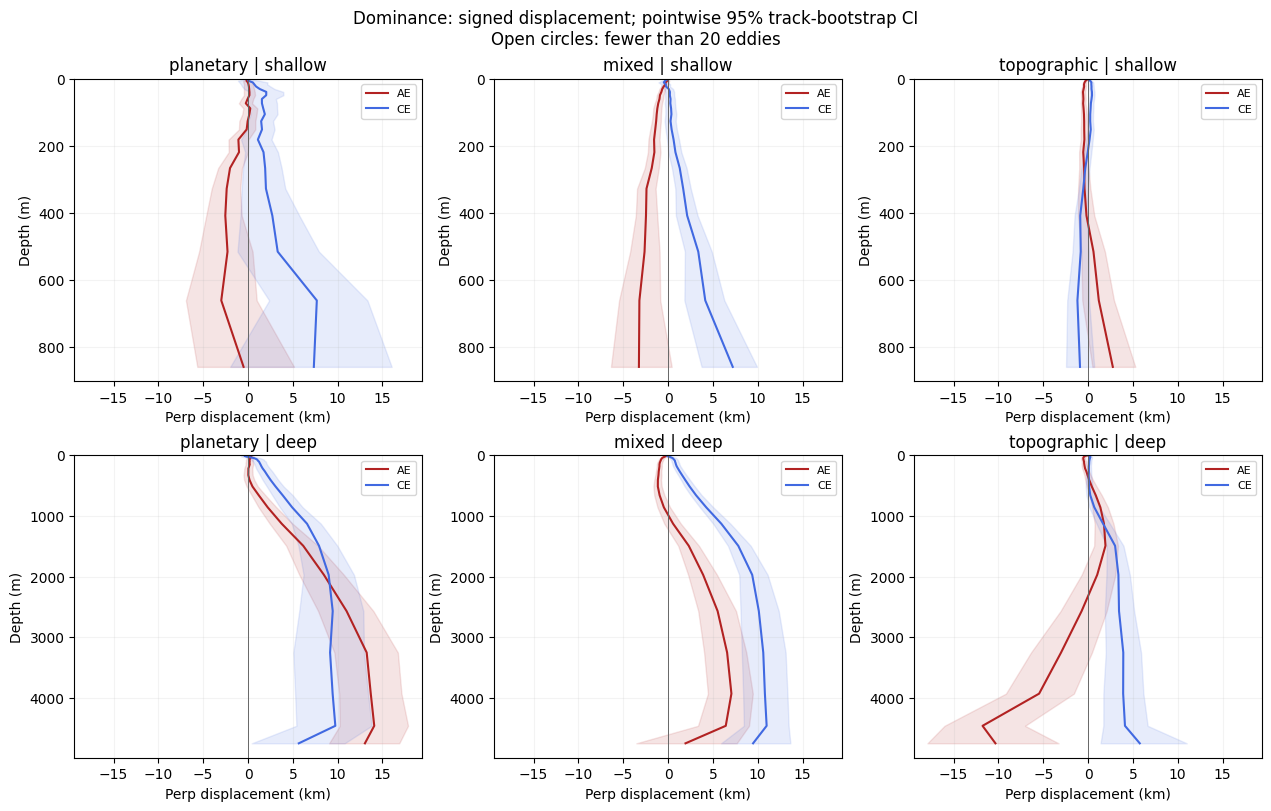

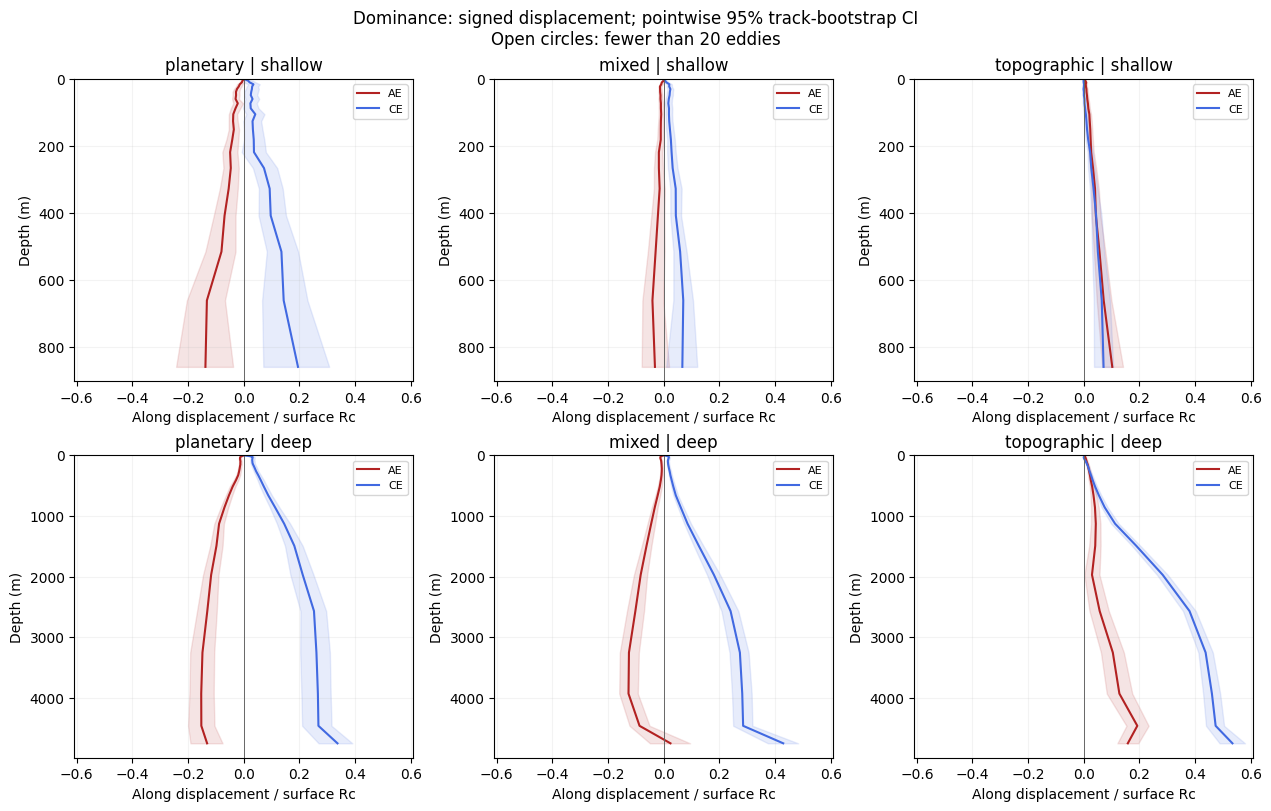

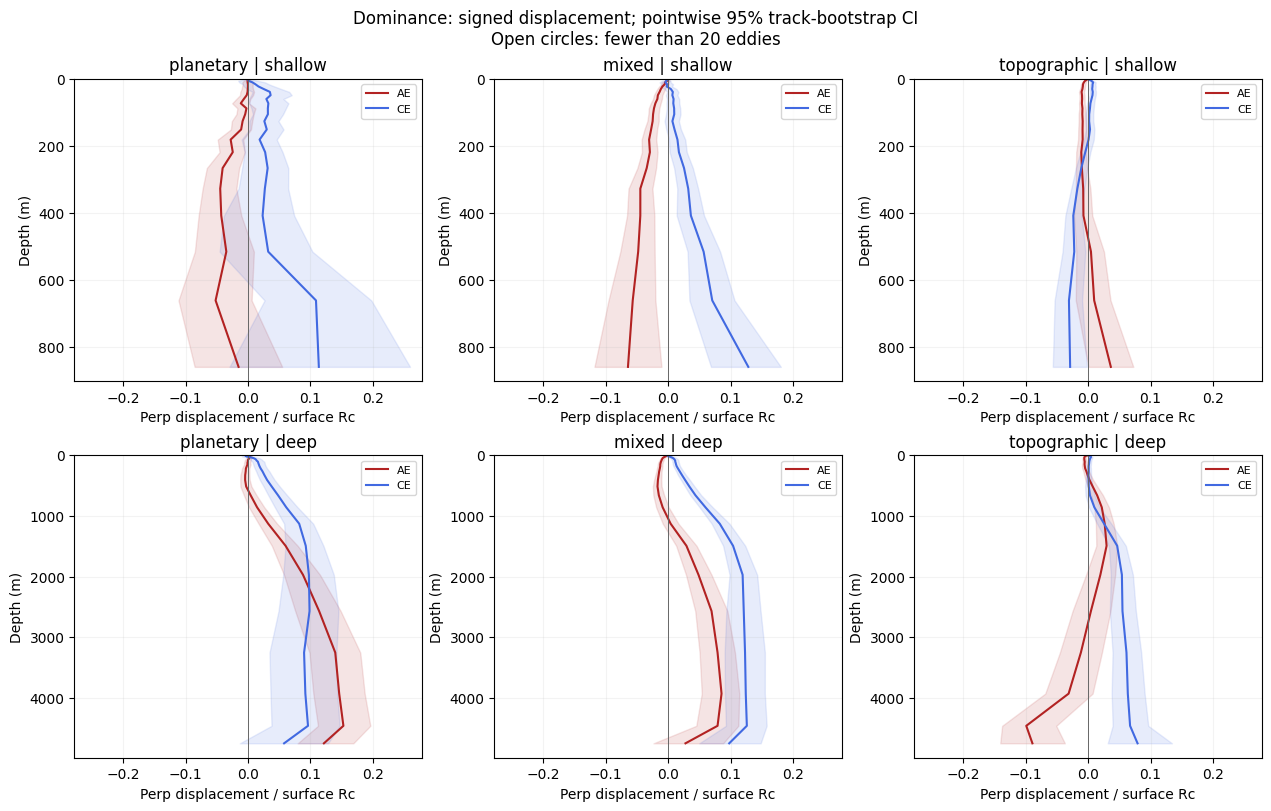

In [8]:
for unit in ['km','Rc']:
    for component in ['along','perp']:
        pvt.plot_profiles(profile_stats, family='dominance', unit=unit, component=component,
                          min_eddies=MIN_PLOT_EDDIES, sparse_eddies=SPARSE_EDDIES)
        plt.show()

## Low/high centre spread
Low spread is solid; high spread dashed. Each shallow/deep row uses its own **shared AE/CE median threshold**, as printed above. Regions, Rossby and dominance are pooled. Consult the coverage table before interpreting amplitude differences.

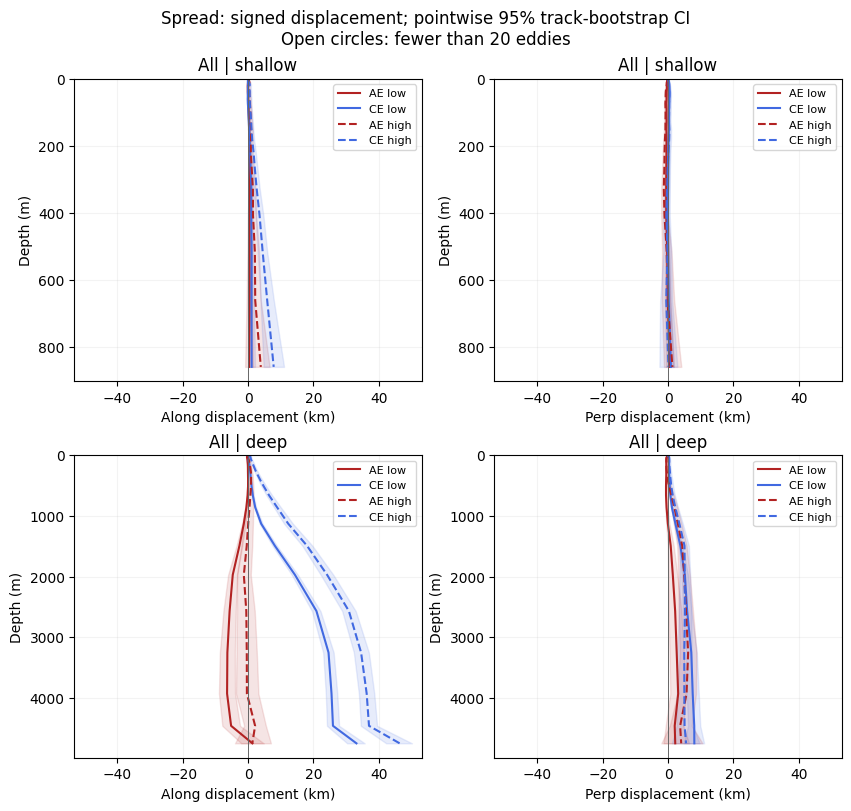

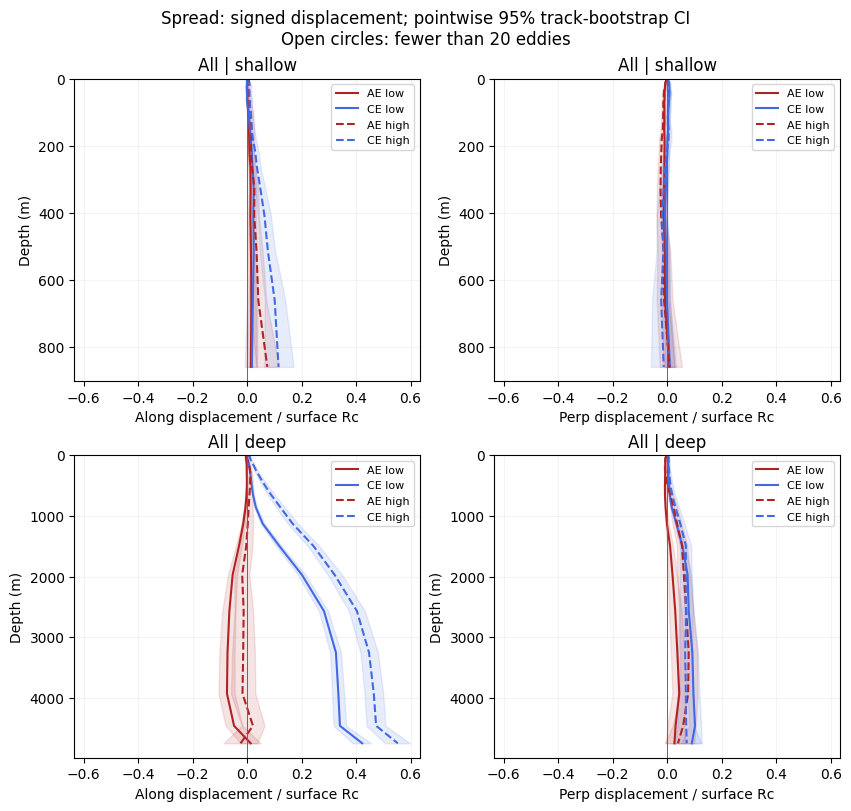

In [9]:
for unit in ['km','Rc']:
    pvt.plot_profiles(profile_stats, family='spread', unit=unit,
                      min_eddies=MIN_PLOT_EDDIES, sparse_eddies=SPARSE_EDDIES)
    plt.show()

## With versus against at common depths
Resolve requested depths once on the common fitted-depth grid, within the specified tolerance; never choose a different depth for each group. Unavailable group/depth combinations stay absent. Labels show directional **eddies/days**. The dotted 0.5 line means equal with/against frequency; an interval above/below it describes directional preference in this sample, without establishing a causal mechanism.

,target_m,Depth,status
0,200.0,181.264793,ok
1,500.0,515.416489,ok
2,1000.0,NaN,unresolved/duplicate fitted depth
3,1500.0,1492.971178,ok


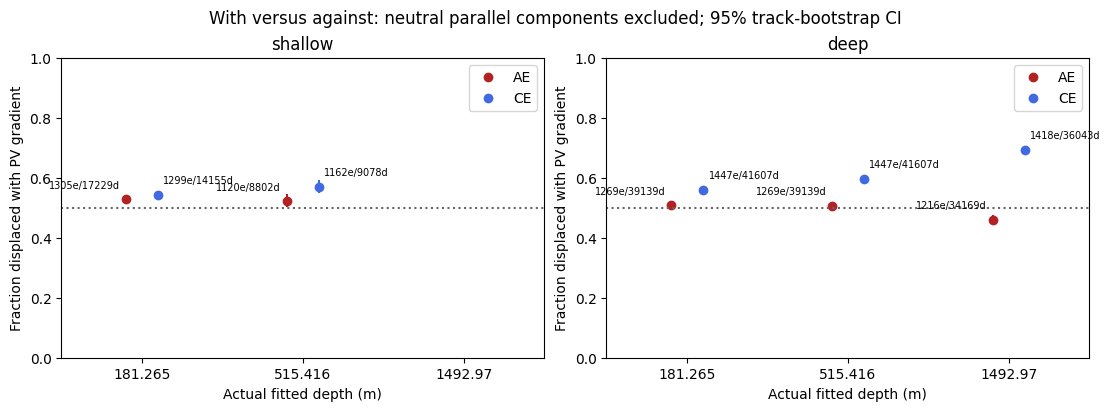

,extent_group,Cyc,Depth,n_eddies,n_eddy_days,directional_days,directional_eddies,neutral_days,fraction_with,fraction_with_ci_low,fraction_with_ci_high,fraction_against
14,shallow,AE,181.264793,1305,17229,17229,1305,0,0.529108,0.515489,0.541938,0.470892
19,shallow,AE,515.416489,1120,8802,8802,1120,0,0.522722,0.501525,0.545576,0.477278
36,shallow,CE,181.264793,1299,14155,14155,1299,0,0.544401,0.530232,0.557281,0.455599
41,shallow,CE,515.416489,1162,9078,9078,1162,0,0.570390,0.549273,0.591704,0.429610
58,deep,AE,181.264793,1269,39139,39139,1269,0,0.507984,0.497215,0.517348,0.492016
63,deep,AE,515.416489,1269,39139,39139,1269,0,0.507218,0.494080,0.519115,0.492782
67,deep,AE,1492.971178,1216,34169,34169,1216,0,0.460330,0.442014,0.477492,0.539670
88,deep,CE,181.264793,1447,41607,41607,1447,0,0.560002,0.549924,0.569912,0.439998
93,deep,CE,515.416489,1447,41607,41607,1447,0,0.597496,0.585612,0.607947,0.402504
97,deep,CE,1492.971178,1418,36043,36043,1418,0,0.693616,0.679642,0.706649,0.306384


In [10]:
direction_summary, direction_depth_map = pvt.direction_at_depths(
    profile_stats, DIRECTION_DEPTHS_M, DEPTH_TOLERANCE_M)
display(direction_depth_map)
pvt.plot_direction(direction_summary, min_eddies=MIN_PLOT_EDDIES)
plt.show()
display(direction_summary[['extent_group','Cyc','Depth','n_eddies','n_eddy_days',
    'directional_days','directional_eddies','neutral_days','fraction_with',
    'fraction_with_ci_low','fraction_with_ci_high','fraction_against']])

## PV cancellation sensitivity
`cancellation_ratio = PV_grad_mag / (PV_grad_plan_mag + PV_grad_topo_mag)`. Small ratios identify a resultant much weaker than its component magnitudes. This is a cancellation diagnostic, **not a calibrated uncertainty in gradient direction**; a small absolute gradient need not imply cancellation.

The baseline keeps every finite positive reference magnitude. The dashed sensitivity curves keep ratios ≥`CANCELLATION_MIN` (default 0.1); unknown component magnitudes are excluded from this sensitivity only. The distributions below show both cancellation and absolute magnitude. No automatic absolute-magnitude cutoff is imposed.

eddy_days  eddies  retained_days  median_cancellation_ratio  \
extent_group Cyc                                                                
deep         AE       39139    1269          39027                   0.861312   
             CE       41607    1447          41507                   0.932772   
shallow      AE       22414    1383          22315                   0.921997   
             CE       17383    1398          17351                   0.954707   

                  p10_PV_grad_mag  median_PV_grad_mag  
extent_group Cyc                                       
deep         AE      3.567808e-15        9.833272e-15  
             CE      4.913572e-15        3.051222e-14  
shallow      AE      4.350193e-15        2.404634e-14  
             CE      6.657618e-15        6.956262e-14

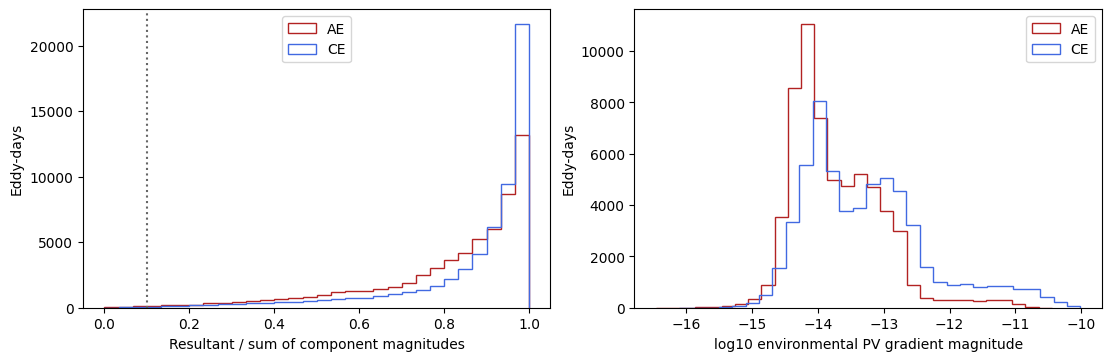

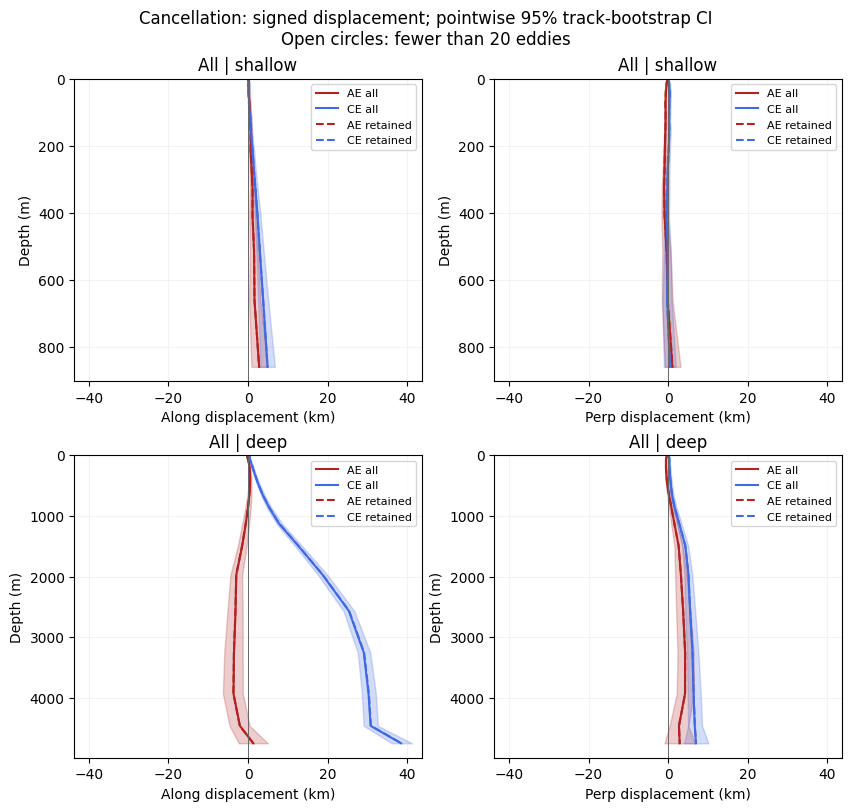

In [11]:
cancellation_audit = eligible.groupby(['extent_group','Cyc']).agg(
    eddy_days=('Day','size'), eddies=('Eddy','nunique'),
    retained_days=('cancellation_ok','sum'),
    median_cancellation_ratio=('cancellation_ratio','median'),
    p10_PV_grad_mag=('PV_grad_mag',lambda x:x.quantile(.1)),
    median_PV_grad_mag=('PV_grad_mag','median'),
)
display(cancellation_audit)
fig,axs = plt.subplots(1,2,figsize=(11,3.5),constrained_layout=True)
for cyc in ['AE','CE']:
    d=eligible.loc[eligible.Cyc.eq(cyc)]
    axs[0].hist(d.cancellation_ratio.dropna(),bins=np.linspace(0,1,31),histtype='step',label=cyc,color=pvt.COLORS[cyc])
    axs[1].hist(np.log10(d.PV_grad_mag),bins=30,histtype='step',label=cyc,color=pvt.COLORS[cyc])
axs[0].axvline(CANCELLATION_MIN,color='.4',ls=':')
axs[0].set(xlabel='Resultant / sum of component magnitudes',ylabel='Eddy-days')
axs[1].set(xlabel='log10 environmental PV gradient magnitude',ylabel='Eddy-days')
for ax in axs: ax.legend()
plt.show()
pvt.plot_profiles(profile_stats,family='cancellation',unit='km',
                  min_eddies=MIN_PLOT_EDDIES,sparse_eddies=SPARSE_EDDIES)
plt.show()

## Changing depth support: fixed-membership sensitivity
A mean profile can change because different days survive at greater depths. The support counts above expose this. This optional check retains only eddy-days present at every target fitted depth in their cohort, then plots their complete profiles. Membership is constant **at those target depths**; at other plotted depths, consult the support counts. Targets are resolved globally; unresolved or duplicate mappings skip that cohort explicitly. Requiring deeper targets selects a different population, so use this as a sensitivity check, not a replacement baseline.

,extent_group,target_m,Depth,status
0,shallow,0.0,0.000000,ok
1,shallow,200.0,181.264793,ok
2,shallow,500.0,515.416489,ok
3,deep,0.0,0.000000,ok
4,deep,200.0,181.264793,ok
5,deep,500.0,515.416489,ok
6,deep,1000.0,NaN,unresolved/duplicate fitted depth
7,deep,1500.0,1492.971178,ok


,family,panel,extent_group,split,Cyc,n_eddy_days,n_eddies
0,matched,All,shallow,all,AE,8802,1120
1,matched,All,shallow,all,CE,9078,1162
2,matched,All,deep,all,AE,0,0
3,matched,All,deep,all,CE,0,0


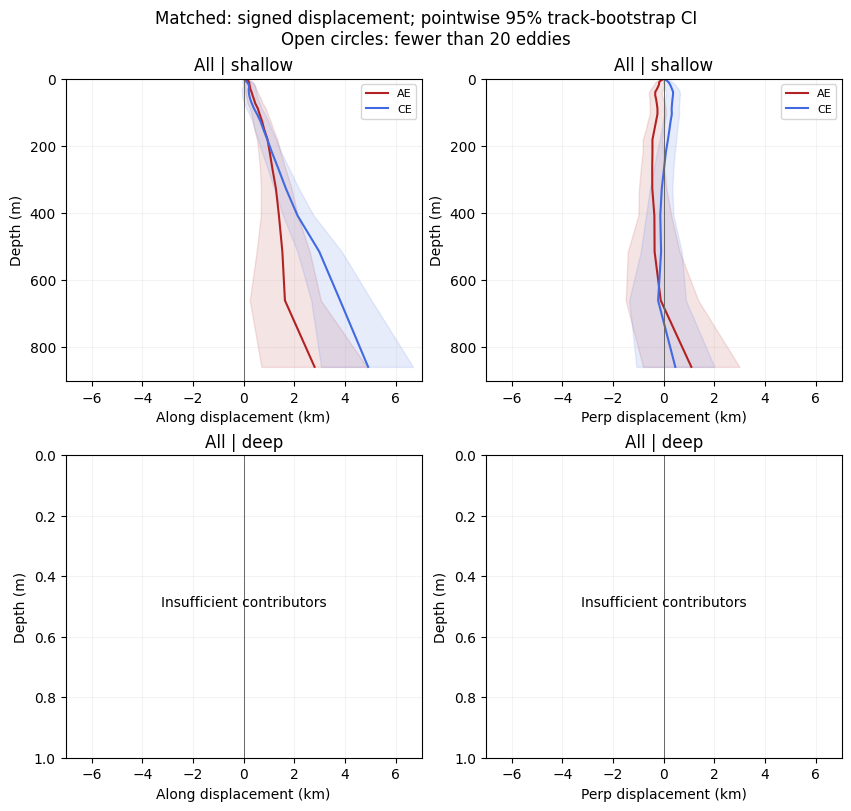

In [12]:
matched_stats = pd.DataFrame()
matched_inventory = pd.DataFrame()
matched_depth_map = pd.DataFrame()
if RUN_MATCHED_SENSITIVITY:
    matched, matched_depth_map = pvt.matched_profiles(members, MATCH_TARGETS_M, DEPTH_TOLERANCE_M)
    display(matched_depth_map)
    matched_stats, matched_inventory = pvt.analyse(matched,n_boot=BOOTSTRAPS,seed=SEED,families=('matched',))
    display(matched_inventory)
    pvt.plot_profiles(matched_stats,family='matched',unit='km',
                      min_eddies=MIN_PLOT_EDDIES,sparse_eddies=SPARSE_EDDIES)
    plt.show()

## Reusable tables and interpretation
Inspect `profile_stats` for parallel/perpendicular means and variances, `direction_summary` for with/against preference, and `members` for the underlying constituent displacements. Use `day_audit` and `support` to explain exclusions and changing sample composition.

Look for agreement between the signed mean and directional fraction; disagreement can indicate that a few large displacements dominate the mean. Check whether patterns persist under the cancellation and fixed-membership sensitivities. Region/Rossby, PV regime and centre-spread panels answer separate descriptive questions; they are not independent hypothesis tests or controls for all confounding.

Optional exports overwrite fixed filenames in one output folder. This does not create another surface PV cache. No physical conclusions are supplied until this notebook is run on the dataset.

In [13]:
if SAVE_RESULTS:
    OUTPUT.mkdir(parents=True,exist_ok=True)
    tables = dict(day_audit=day_audit,members=members,spread_thresholds=spread_thresholds,
                  profile_stats=profile_stats,group_inventory=group_inventory,support=support,
                  direction_summary=direction_summary,direction_depth_map=direction_depth_map,
                  matched_stats=matched_stats,matched_inventory=matched_inventory,
                  matched_depth_map=matched_depth_map)
    for name,table in tables.items(): table.to_parquet(OUTPUT/f'{name}.parquet',index=False)
    settings = dict(use_max_abs_w=USE_MAX_ABS_W,w_max_depth_m=W_MAX_DEPTH_M,
        split_depth_m=SPLIT_DEPTH_M,spread_max_depth_m=SPREAD_MAX_DEPTH_M,
        rossby_split=ROSSBY_SPLIT,dominance_factor=DOMINANCE_FACTOR,
        cancellation_min=CANCELLATION_MIN,bootstraps=BOOTSTRAPS,seed=SEED,
        pv_reference=['PV_grad_mag','PV_grad_theta'],ellipse_frac=ELLIPSE_FRAC,
        pv_cache_settings=surface.attrs.get('surface_pv_cache_settings'),
        pv_cache_created_utc=surface.attrs.get('surface_pv_cache_created_utc'))
    (OUTPUT/'settings.json').write_text(json.dumps(settings,indent=2))
    print('Overwrote current analysis tables in',OUTPUT)